<a href="https://colab.research.google.com/github/isxd0r4/previsaoRiscoDeTsunami/blob/main/tsunamiRiskAssessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!curl -L -o /content/global-earthquake-tsunami-risk-assessment-dataset.zip\
    https://www.kaggle.com/api/v1/datasets/download/ahmeduzaki/global-earthquake-tsunami-risk-assessment-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 16151  100 16151    0     0  38781      0 --:--:-- --:--:-- --:--:-- 38781


In [ ]:
!unzip -qq /content/global-earthquake-tsunami-risk-assessment-dataset.zip

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB
None


   magnitude  cdi  mmi  sig  nst   dmin   gap    depth  latitude  longitude  \
0        7.0    8    7  768  117  0.509  17.0   14.000   -9.7963    159.596   
1        6.9    4    4  735   99  2.229  34.0   25.000   -4.9559    100.738   


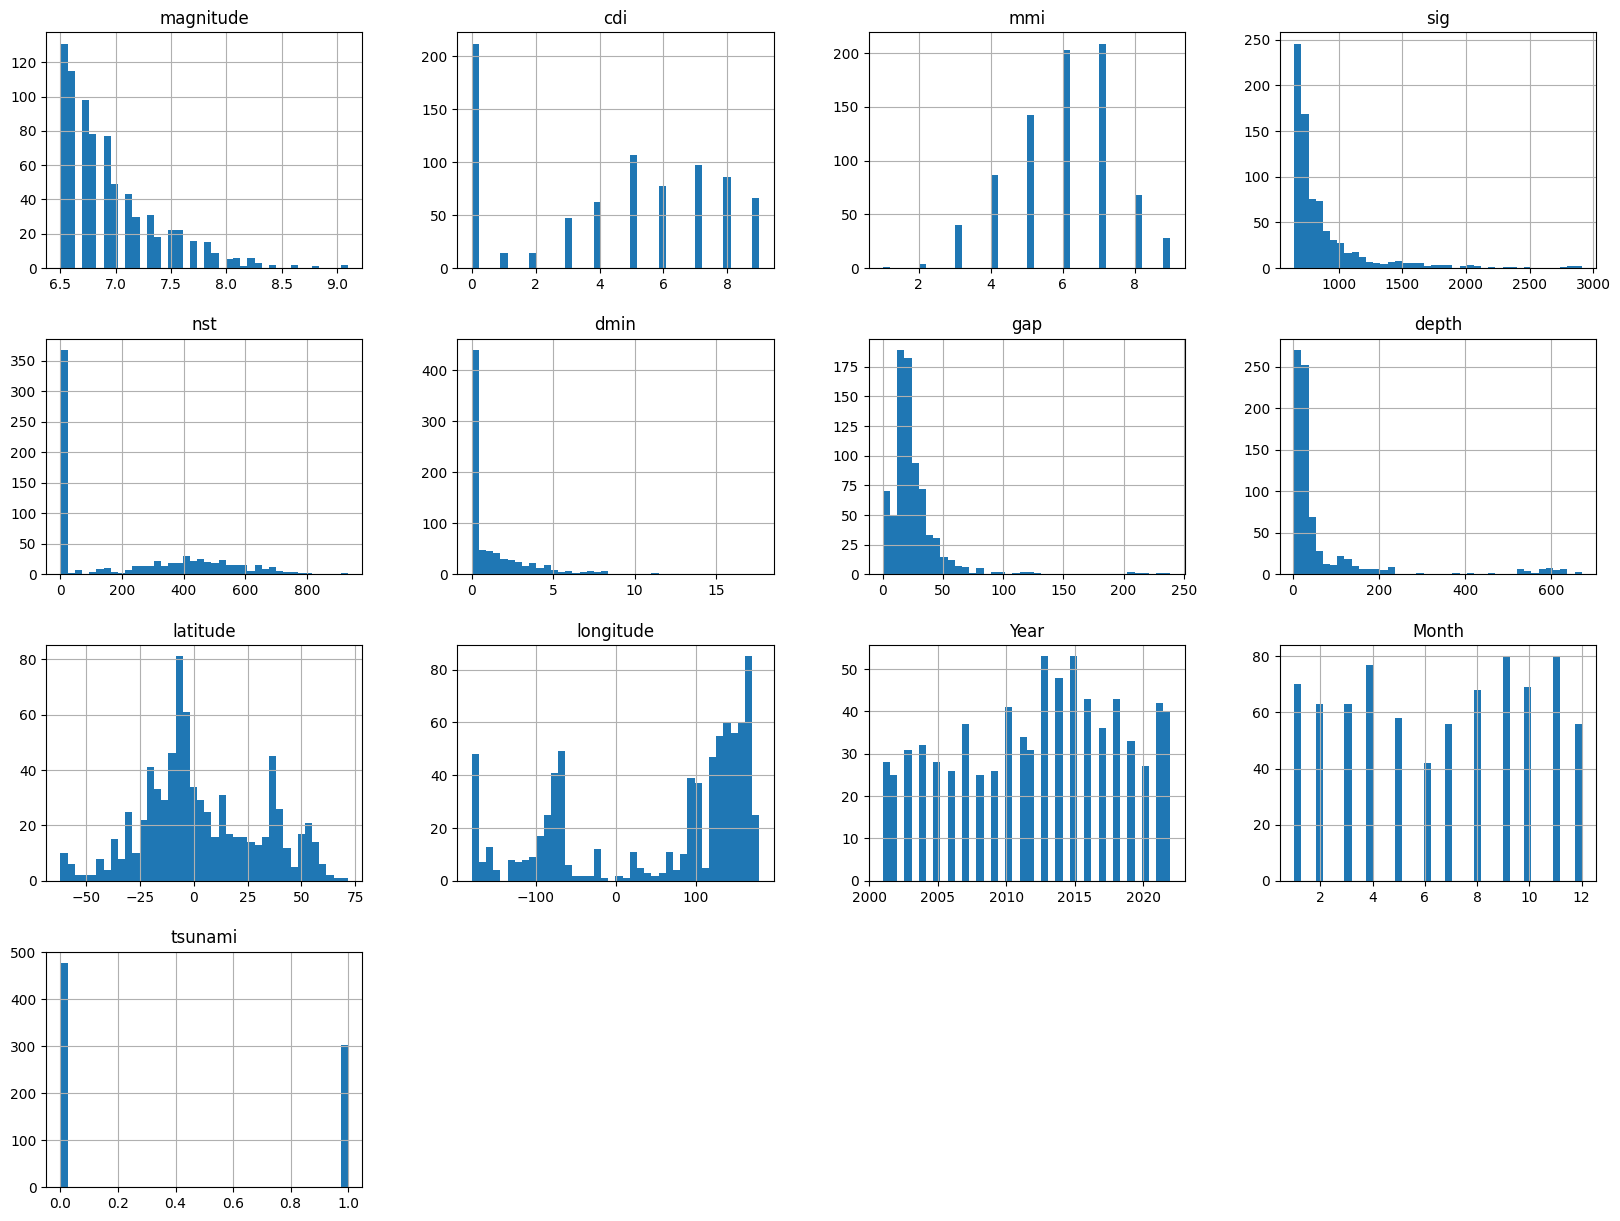

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

tsunami = pd.read_csv("/content/earthquake_data_tsunami.csv")

print(tsunami.info())
print("\n")
print(tsunami.head())
print("\n")

# distribuição geral das variáveis
tsunami.hist(bins = 40, figsize = (20, 15))
plt.show()
print("\n")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# remoção de colunas irrelevantes
colunasIrrelevantes = ['Year', 'Month']
tsunami = tsunami.drop(columns = colunasIrrelevantes, errors = 'ignore')

# separação de variáveis preditoras e variável alvo
x = tsunami.drop('tsunami', axis = 1)
y = tsunami['tsunami']

# divisão treino/teste
xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size = 0.3, random_state = 42, stratify = y)

# padronização dos dados
pipeline = Pipeline ([("scaler", StandardScaler())])

xTrainPrepared = pipeline.fit_transform(xTrain)
xTestPrepared = pipeline.transform(xTest)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# grades de hiperparâmetros
paramGridRF = {
    'n_estimators': [100, 200],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

paramGridLR = {
    'C': [1, 5, 10],
    'max_iter': [500, 1000]
}

paramGridSVM = {
    'C': [1, 5, 10],
    'tol': [0.001, 0.0001]
}

# GridSearchCV para random forest
gridRF = GridSearchCV(
    RandomForestClassifier(random_state = 42),
    paramGridRF,
    cv = 5,
    scoring = "recall"
)

# GridSearchCV para logistic regression
gridLR = GridSearchCV(
    LogisticRegression(random_state = 42),
    paramGridLR,
    cv = 5,
    scoring = "recall"
)

# GridSearchCV para SVM
gridSVM = GridSearchCV(
    LinearSVC(max_iter = 100000),
    paramGridSVM,
    cv = 5,
    scoring = "recall"
)

# treinamento dos modelos
gridRF.fit(xTrainPrepared, yTrain)
gridLR.fit(xTrainPrepared, yTrain)
gridSVM.fit(xTrainPrepared, yTrain)

# melhores modelos
melhorRF = gridRF.best_estimator_
melhorLR = gridLR.best_estimator_
melhorSVM = gridSVM.best_estimator_

# validação cruzada para random forest
cvRF = cross_val_score(melhorRF, xTrainPrepared, yTrain, cv = 5, scoring = "recall")

# validação cruzada para logistic regression
cvLR = cross_val_score(melhorLR, xTrainPrepared, yTrain, cv = 5, scoring = "recall")

# validação cruzada para SVM
cvSVM = cross_val_score(melhorSVM, xTrainPrepared, yTrain, cv = 5, scoring = "recall")

# resultados
print(f"recall - random forest: {cvRF.mean():.2f}")
print(f"recall - regressão logística: {cvLR.mean():.2f}")
print(f"recall - SVM: {cvSVM.mean():.2f}")

recall - random forest: 0.92
recall - regressão logística: 0.85
recall - SVM: 0.87


In [ ]:
from sklearn.metrics import classification_report

# previsões
previsaoRF = melhorRF.predict(xTestPrepared)
previsaoLR = melhorLR.predict(xTestPrepared)
previsaoSVM = melhorSVM.predict(xTestPrepared)

# resultados
print("performance nos dados de teste - random forest:")
print(classification_report(yTest, previsaoRF))

print("\nperformance nos dados de teste - regressão logística:")
print(classification_report(yTest, previsaoLR))

print("\nperformance nos dados de teste - SVM:")
print(classification_report(yTest, previsaoSVM))

performance nos dados de teste - random forest:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       144
           1       0.81      0.89      0.85        91

    accuracy                           0.88       235
   macro avg       0.87      0.88      0.87       235
weighted avg       0.88      0.88      0.88       235


performance nos dados de teste - regressão logística:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83       144
           1       0.70      0.86      0.77        91

    accuracy                           0.80       235
   macro avg       0.80      0.81      0.80       235
weighted avg       0.82      0.80      0.81       235


performance nos dados de teste - SVM:
              precision    recall  f1-score   support

           0       0.90      0.76      0.82       144
           1       0.69      0.87      0.77        91

    accuracy                           0